# 🔍 Étape 6 — Analyse SHAP & Feature Importance

On analyse ici **pourquoi** les modèles font leurs prédictions — c'est un critère de réussite explicite du guide projet.

### Pourquoi SHAP ?
La feature importance classique (MDI pour RF, gain pour XGBoost) dit quelle variable est *globalement* importante.  
SHAP (SHapley Additive exPlanations) va plus loin :
- **Importance globale** : sur tout le jeu de test
- **Impact directionnel** : est-ce qu'une valeur haute de la variable *augmente* ou *diminue* la prédiction ?
- **Importance locale** : pourquoi le modèle a prédit *cette valeur* pour *ce point précis* ?

> On applique SHAP sur **XGBoost** (le plus rapide à expliquer) et la feature importance native sur Random Forest.

### Plan
1. Chargement des modèles et données
2. SHAP sur XGBoost — importance globale (beeswarm + bar)
3. SHAP — impact directionnel (dependence plots)
4. SHAP — explication locale (waterfall sur un point)
5. Feature importance RF vs XGBoost
6. Analyse des variables clés identifiées
7. Conclusions pour le rapport

## 1. Imports et chargement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

SAVE_DIR  = 'preprocessed'
MODEL_DIR = 'models'
HORIZON   = 600

In [13]:
# Données
X_train      = np.load(f'{SAVE_DIR}/X_train.npy')
X_test       = np.load(f'{SAVE_DIR}/X_test.npy')
y_test       = np.load(f'{SAVE_DIR}/y_test.npy')
feature_cols = pd.read_csv(f'{SAVE_DIR}/feature_cols.csv').iloc[:, 0].tolist()
ts_test      = pd.read_csv(f'{SAVE_DIR}/ts_test.csv', parse_dates=[0]).iloc[:, 0]

# Modèles ML
xgb_model = joblib.load(f'{MODEL_DIR}/xgboost_best.pkl')
rf_model  = joblib.load(f'{MODEL_DIR}/random_forest_best.pkl')

print(f"X_test       : {X_test.shape}")
print(f"Features     : {len(feature_cols)}")
print(f"Modèles chargés : XGBoost + Random Forest")

X_test       : (1421, 366)
Features     : 366
Modèles chargés : XGBoost + Random Forest


## 2. Vérification de SHAP

On vérifie que SHAP est disponible. Si l'import échoue, on bascule sur la feature importance native uniquement.

In [14]:
try:
    import shap
    shap.initjs()
    SHAP_AVAILABLE = True
    print(f"✅ SHAP version {shap.__version__} disponible")
except Exception as e:
    SHAP_AVAILABLE = False
    print(f"⚠️  SHAP non disponible ({e})")
    print("   On utilisera uniquement la feature importance native.")
    print("   Pour installer : pip install shap==0.44.1")

✅ SHAP version 0.45.1 disponible


## 3. Sous-échantillonnage pour SHAP

Calculer les valeurs SHAP sur 600k points prendrait des heures.  
On travaille sur un échantillon aléatoire de **2000 points du test** — suffisant pour des conclusions robustes.

In [15]:
N_SHAP = min(2000, len(X_test))
rng    = np.random.default_rng(42)
idx    = rng.choice(len(X_test), size=N_SHAP, replace=False)

X_shap = X_test[idx]
y_shap = y_test[idx]

# DataFrame pour les plots SHAP (noms de colonnes lisibles)
df_shap = pd.DataFrame(X_shap, columns=feature_cols)

print(f"Échantillon SHAP : {X_shap.shape}")

Échantillon SHAP : (1421, 366)


## 4. SHAP sur XGBoost

On utilise le **TreeExplainer** de SHAP — optimisé pour les modèles basés sur des arbres (XGBoost, RF).  
Il calcule les valeurs SHAP exactes en temps polynomial grâce à la structure des arbres.

Chaque valeur SHAP représente la **contribution marginale** d'une feature à la prédiction, par rapport à la prédiction moyenne du modèle.

In [16]:
if SHAP_AVAILABLE:
    print("Calcul des valeurs SHAP (Random Forest)...")
    explainer   = shap.TreeExplainer(rf_model)
    shap_values = explainer(df_shap)
    print(f"✅ Valeurs SHAP calculées : {shap_values.values.shape}")

Calcul des valeurs SHAP (Random Forest)...
✅ Valeurs SHAP calculées : (1421, 366)


### 4a. Beeswarm plot — Vue d'ensemble

Le beeswarm est le graphique SHAP le plus informatif :
- **Axe X** : valeur SHAP (impact sur la prédiction)
- **Couleur** : valeur de la feature (rouge = élevée, bleu = faible)
- **Chaque point** = un échantillon

Un point rouge à droite signifie : *quand cette feature est élevée, elle pousse la prédiction vers le haut*.

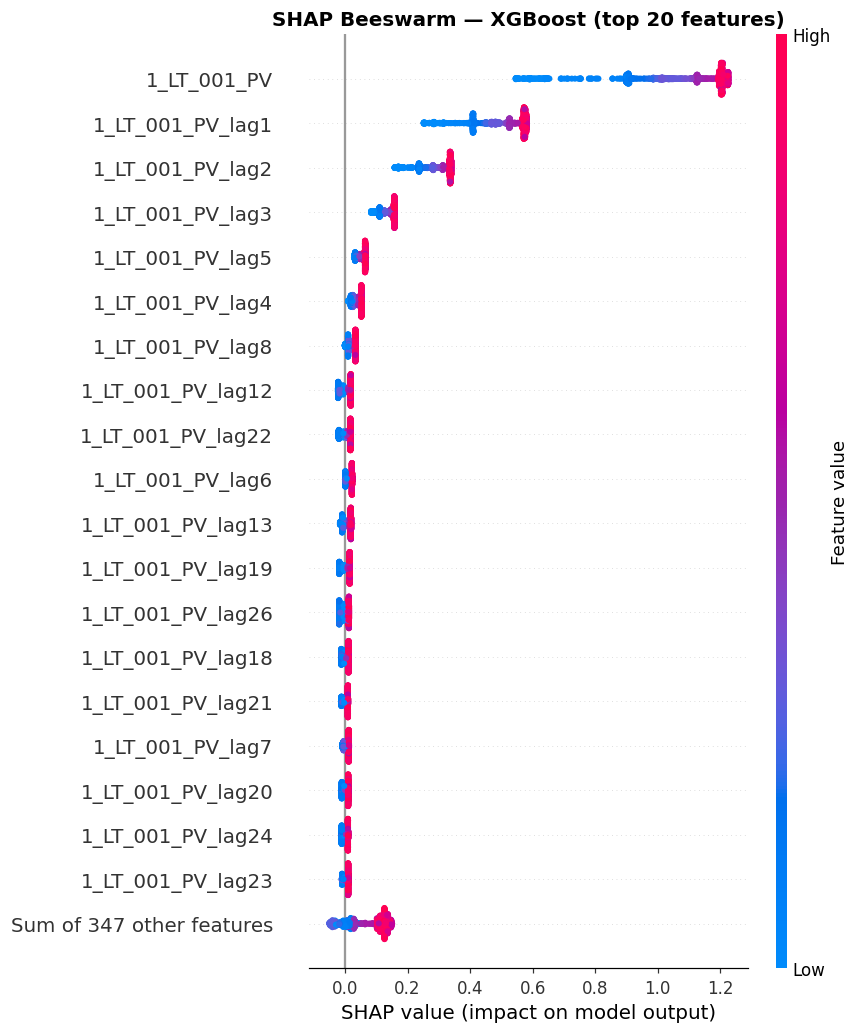

In [11]:
if SHAP_AVAILABLE:
    plt.figure(figsize=(11, 9))
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title('SHAP Beeswarm — XGBoost (top 20 features)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4b. Bar plot — Importance globale moyenne

Résumé plus simple : importance moyenne de chaque feature sur l'ensemble des prédictions.  
Équivalent à `mean(|SHAP value|)` pour chaque feature.

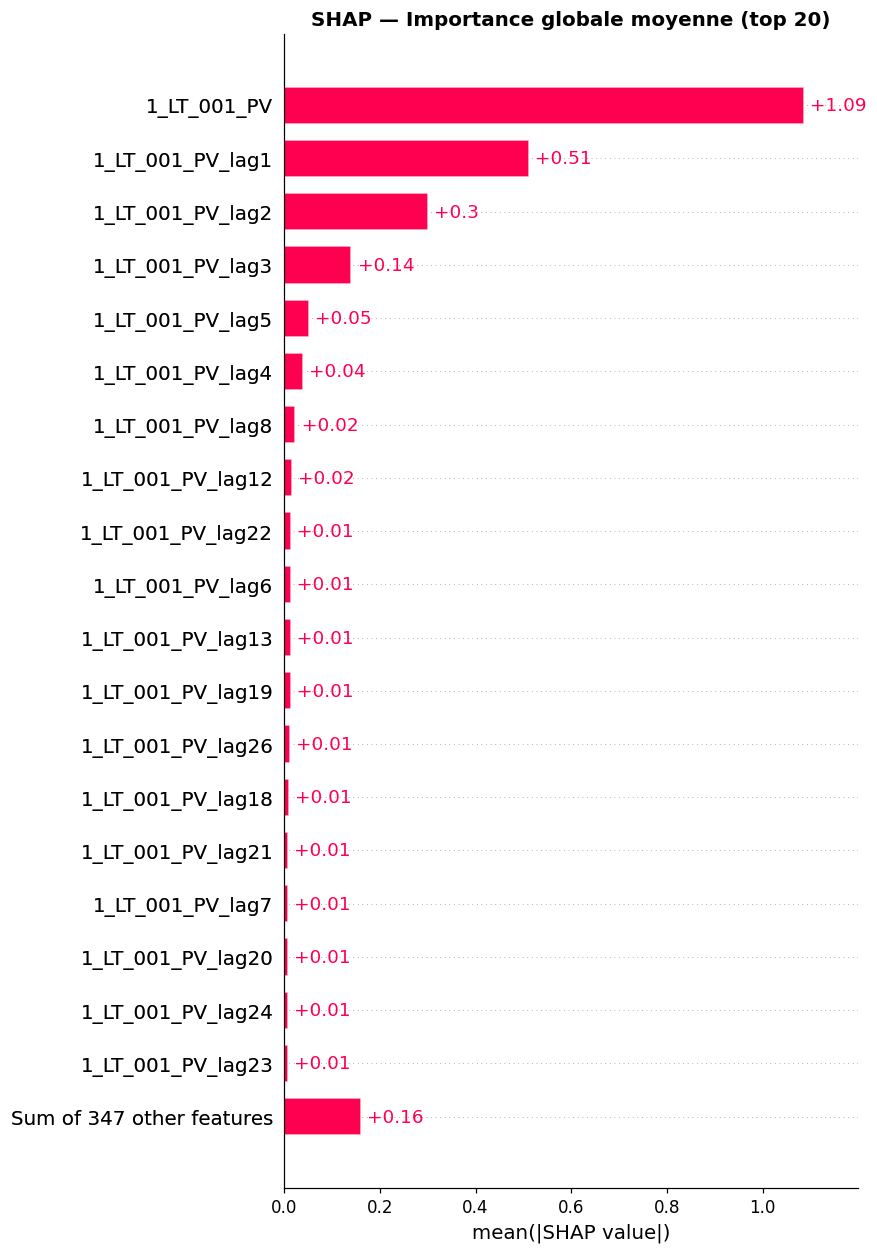

Top 15 features par importance SHAP :
1_LT_001_PV          1.087003
1_LT_001_PV_lag1     0.511510
1_LT_001_PV_lag2     0.300401
1_LT_001_PV_lag3     0.140676
1_LT_001_PV_lag5     0.051878
1_LT_001_PV_lag4     0.039904
1_LT_001_PV_lag8     0.023666
1_LT_001_PV_lag12    0.016774
1_LT_001_PV_lag22    0.014677
1_LT_001_PV_lag6     0.014338
1_LT_001_PV_lag13    0.014107
1_LT_001_PV_lag19    0.013625
1_LT_001_PV_lag26    0.011646
1_LT_001_PV_lag18    0.009530
1_LT_001_PV_lag21    0.008418


In [17]:
if SHAP_AVAILABLE:
    plt.figure(figsize=(10, 8))
    shap.plots.bar(shap_values, max_display=20, show=False)
    plt.title('SHAP — Importance globale moyenne (top 20)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tableau des importances SHAP triées
    mean_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=feature_cols
    ).sort_values(ascending=False)

    print("Top 15 features par importance SHAP :")
    print(mean_shap.head(15).to_string())

### 4c. Dependence plots — Impact directionnel

On trace la relation entre la valeur d'une feature et sa valeur SHAP.  
Cela révèle si l'effet est **linéaire, non-linéaire, ou avec seuil**.  
La couleur indique une feature d'interaction détectée automatiquement par SHAP.

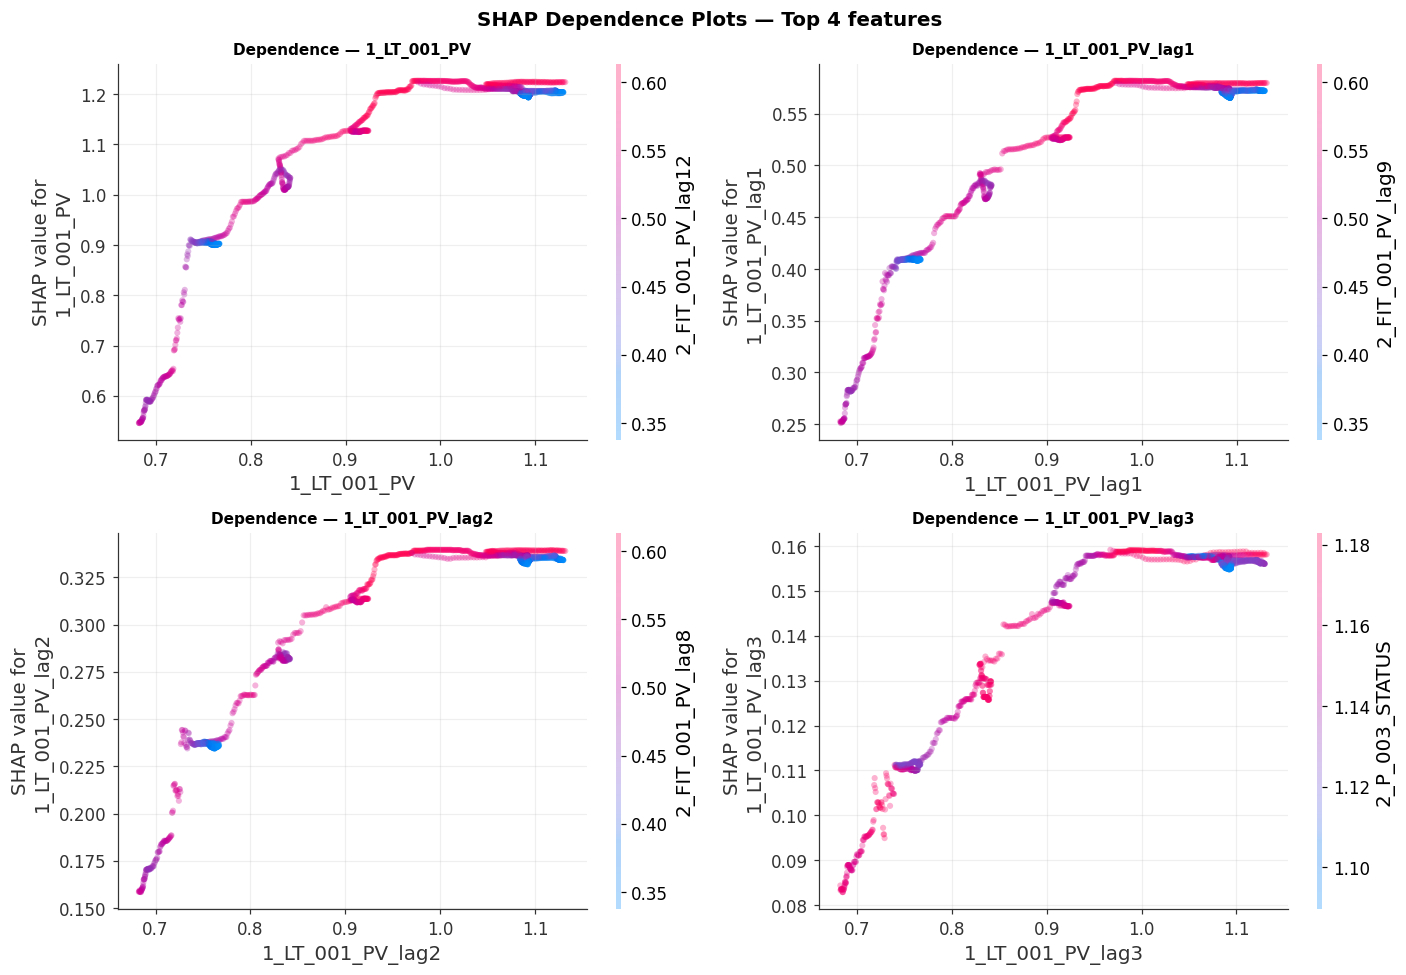

In [18]:
if SHAP_AVAILABLE:
    # Top 4 features les plus importantes
    top4 = mean_shap.head(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, feat in zip(axes.ravel(), top4):
        feat_idx = feature_cols.index(feat)
        shap.dependence_plot(
            feat_idx, shap_values.values, df_shap,
            ax=ax, show=False, alpha=0.3
        )
        ax.set_title(f'Dependence — {feat}', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.2)

    plt.suptitle('SHAP Dependence Plots — Top 4 features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4d. Waterfall plot — Explication locale

On explique **une prédiction individuelle** : pourquoi le modèle a prédit cette valeur précise ?  
Le waterfall décompose la prédiction en contributions de chaque feature, à partir de la valeur de base (prédiction moyenne).

On choisit un point avec une **grosse erreur** pour voir ce que le modèle a raté.

Point analysé (index 1305) :
  Valeur réelle   : 58.9590
  Valeur prédite  : 57.3952
  Erreur absolue  : 1.5638


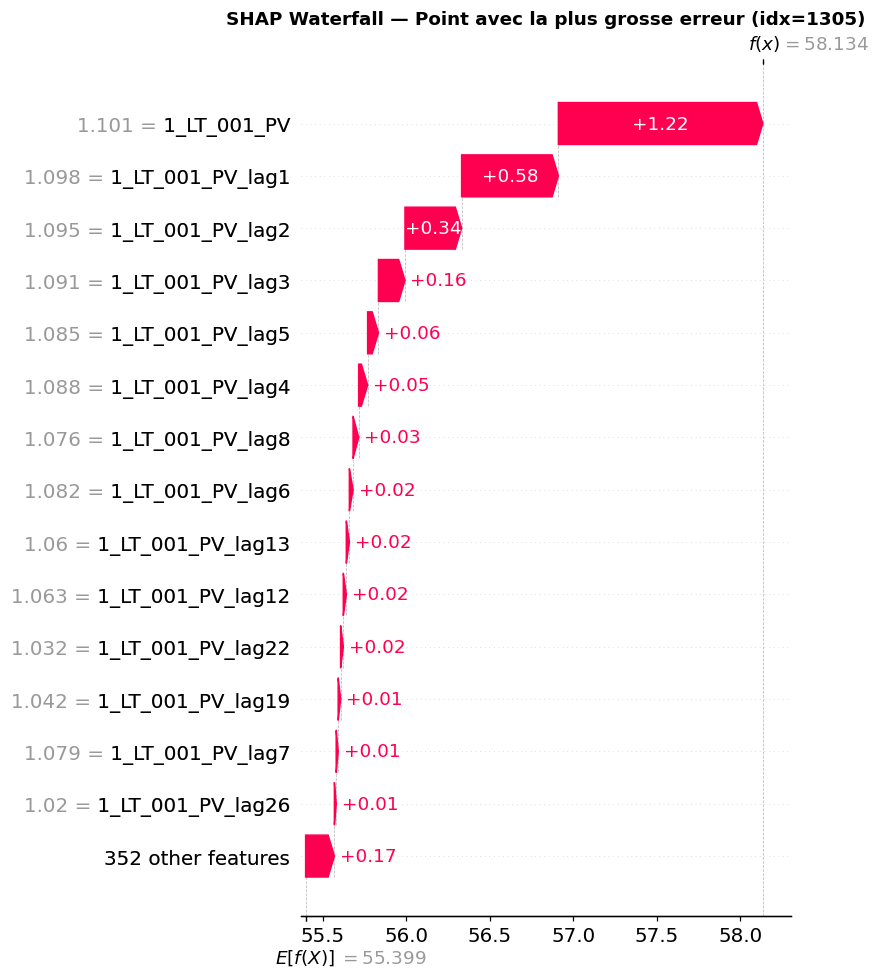

In [19]:
if SHAP_AVAILABLE:
    y_pred_shap = xgb_model.predict(X_shap)
    errors      = np.abs(y_shap - y_pred_shap)

    # Point avec la plus grosse erreur
    worst_idx = int(np.argmax(errors))
    print(f"Point analysé (index {worst_idx}) :")
    print(f"  Valeur réelle   : {y_shap[worst_idx]:.4f}")
    print(f"  Valeur prédite  : {y_pred_shap[worst_idx]:.4f}")
    print(f"  Erreur absolue  : {errors[worst_idx]:.4f}")

    plt.figure(figsize=(11, 7))
    shap.plots.waterfall(shap_values[worst_idx], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Point avec la plus grosse erreur (idx={worst_idx})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Feature Importance native — RF vs XGBoost

Même si SHAP n'est pas disponible, on peut utiliser la feature importance native des deux modèles.  
On compare RF (MDI) et XGBoost (gain) pour voir si elles s'accordent sur les variables clés.

**Un bon signe** : les deux modèles s'accordent sur les mêmes top features → résultat robuste.

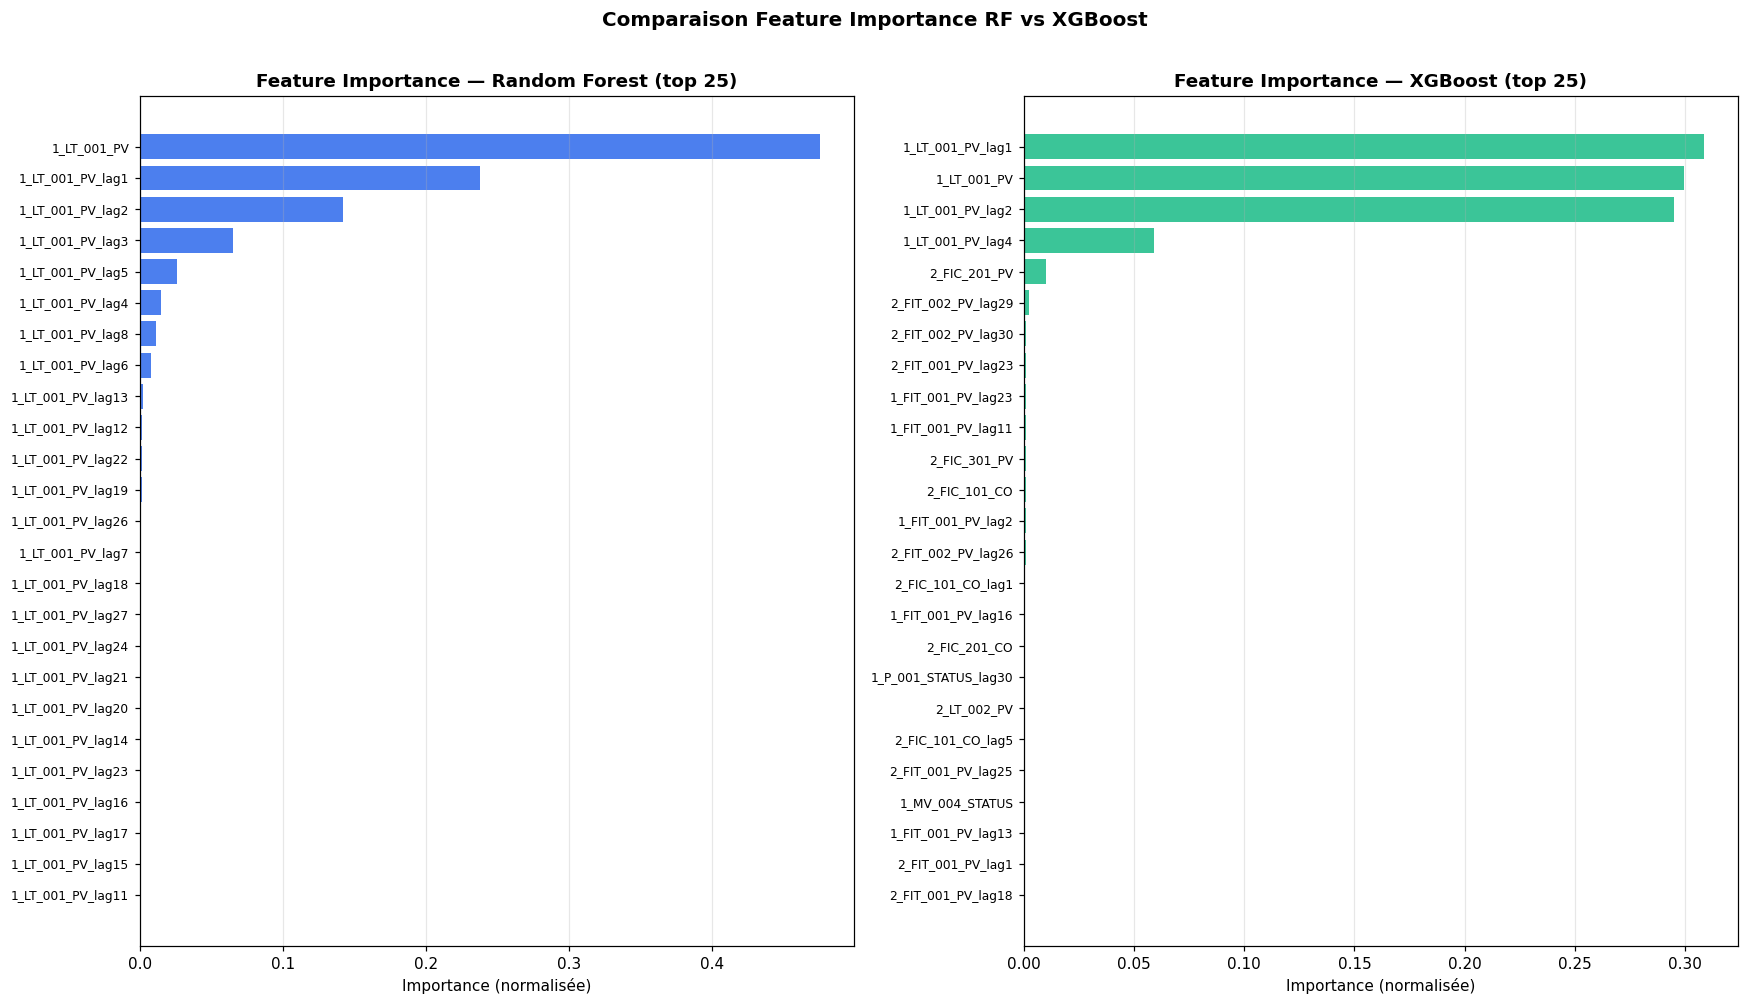

In [20]:
TOP_N = 25

# Importances normalisées
imp_rf  = pd.Series(rf_model.feature_importances_,  index=feature_cols)
imp_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols)

# Top N union des deux modèles
top_rf  = imp_rf.nlargest(TOP_N)
top_xgb = imp_xgb.nlargest(TOP_N)
all_top = list(set(top_rf.index) | set(top_xgb.index))

df_imp = pd.DataFrame({
    'Random Forest': imp_rf[all_top],
    'XGBoost':       imp_xgb[all_top]
}).fillna(0).sort_values('XGBoost', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, col, color in zip(axes, ['Random Forest', 'XGBoost'], ['#2563EB', '#10B981']):
    df_sorted = df_imp.sort_values(col, ascending=True).tail(TOP_N)
    ax.barh(df_sorted.index, df_sorted[col], color=color, alpha=0.82)
    ax.set_xlabel('Importance (normalisée)')
    ax.set_title(f'Feature Importance — {col} (top {TOP_N})',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Comparaison Feature Importance RF vs XGBoost', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5a. Corrélation entre les deux importances

On mesure à quel point RF et XGBoost s'accordent sur le classement des features.  
Une corrélation de Spearman élevée (>0.7) indique que les deux modèles exploitent les mêmes structures dans les données.

Corrélation de Spearman RF vs XGBoost : 0.476  (p=4.37e-22)
⚠️  Les modèles divergent — les features exploitées sont différentes


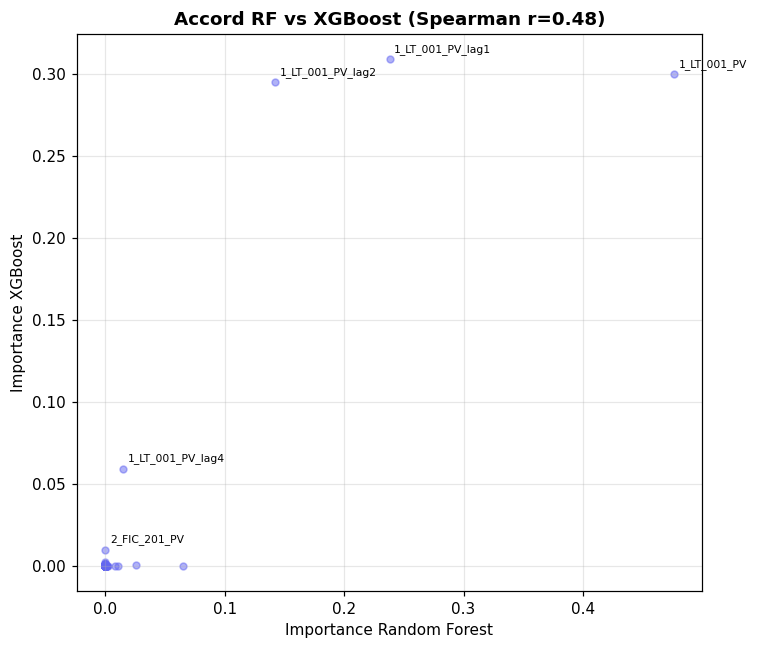

In [21]:
from scipy.stats import spearmanr

corr_spearman, pval = spearmanr(imp_rf, imp_xgb)
print(f"Corrélation de Spearman RF vs XGBoost : {corr_spearman:.3f}  (p={pval:.2e})")

if corr_spearman > 0.7:
    print("✅ Les deux modèles s'accordent bien sur les features importantes")
else:
    print("⚠️  Les modèles divergent — les features exploitées sont différentes")

# Scatter des importances
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(imp_rf, imp_xgb, alpha=0.5, s=20, color='#6366F1')

# Annoter les top 5
for feat in imp_xgb.nlargest(5).index:
    ax.annotate(feat, (imp_rf[feat], imp_xgb[feat]),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Importance Random Forest')
ax.set_ylabel('Importance XGBoost')
ax.set_title(f'Accord RF vs XGBoost (Spearman r={corr_spearman:.2f})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Analyse des variables clés identifiées

On visualise comment les **top features** évoluent en relation avec la cible sur la période de test.  
C'est le **"visual check"** demandé dans le guide projet : est-ce que le modèle réagit correctement aux activations de pompes/vannes ?

Top features (agrégées sur les lags) : ['2_FIC_201_PV', '1_FIT_001_PV', '2_FIT_002_PV', '2_FIT_001_PV']


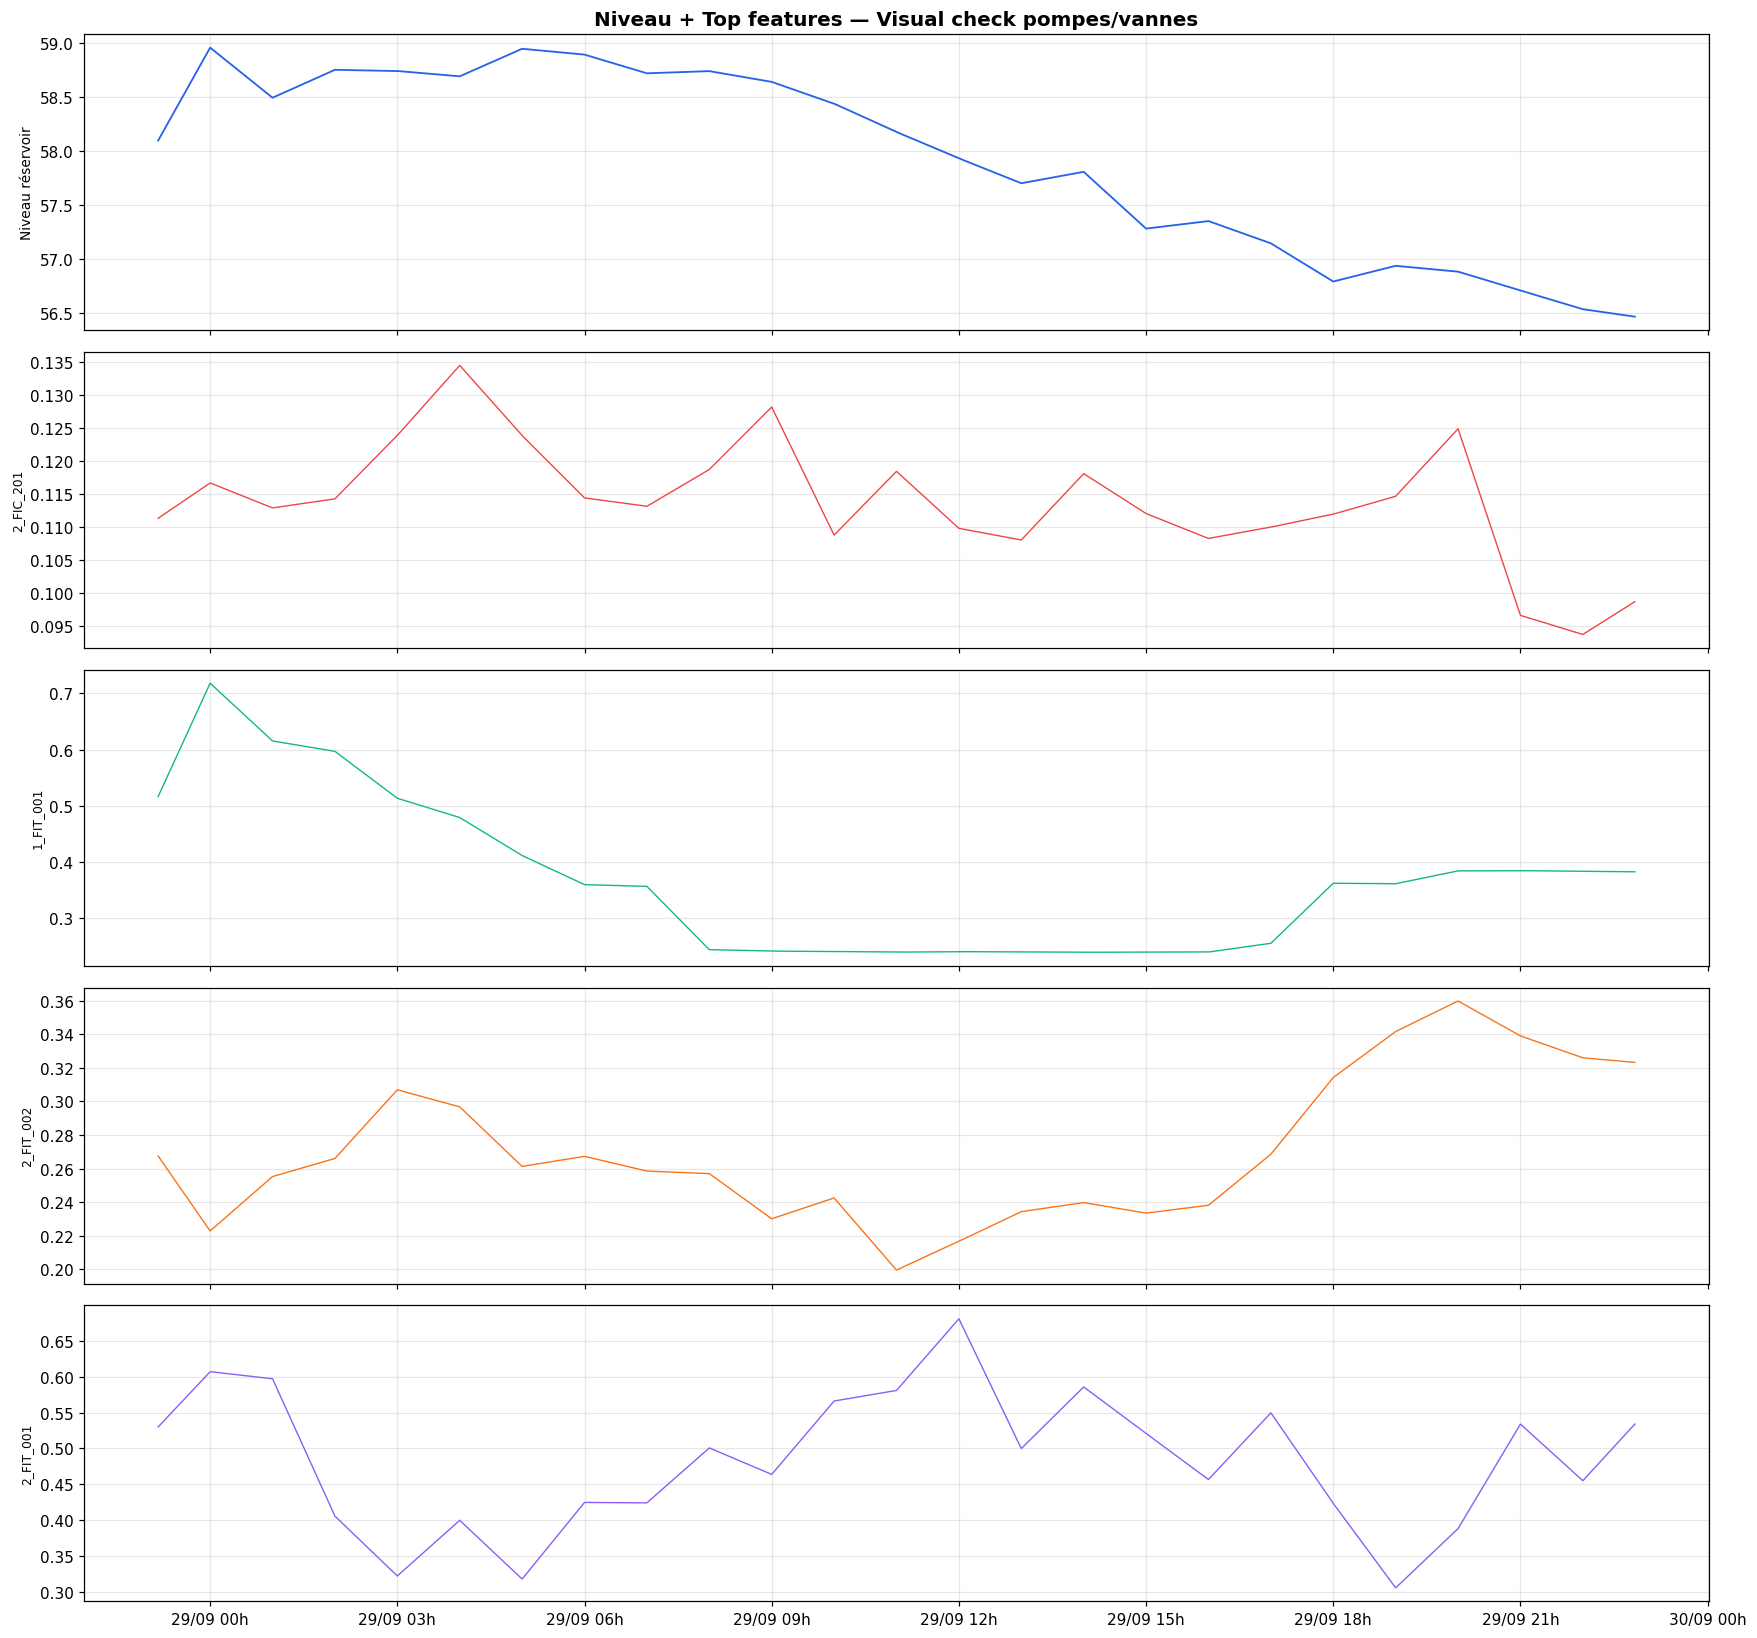

In [22]:
# Chargement des donnees avec la methode corrigee (Row = 1 seconde)
df_raw = pd.read_csv("WADI_14days_new.csv")
START_TIME = pd.Timestamp("2017-09-25 00:00:00")
df_raw["datetime"] = START_TIME + pd.to_timedelta(df_raw["Row"] - 1, unit="s")
df_raw = df_raw.drop(columns=["Row", "Date", "Time"], errors="ignore")
for col in df_raw.columns:
    if col != "datetime":
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
df_raw = df_raw.set_index("datetime").sort_index()

TARGET = "1_LT_001_PV"

# Top 4 features non-laggees les plus importantes
base_imp = imp_xgb.copy()
base_imp.index = [c.split("_lag")[0] for c in base_imp.index]
base_imp = base_imp.groupby(level=0).sum().sort_values(ascending=False)
top4_base = [f for f in base_imp.head(6).index if f in df_raw.columns and f != TARGET][:4]

print(f"Top features (agregees sur les lags) : {top4_base}")

# Zoom sur 3 jours du test
zoom_start = ts_test.iloc[0]
zoom_end   = ts_test.iloc[min(3*86400, len(ts_test)-1)]  # 3 jours en secondes
df_zoom    = df_raw.loc[zoom_start:zoom_end]

n_plots = len(top4_base) + 1
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 3 * n_plots), sharex=True)

axes[0].plot(df_zoom.index, df_zoom[TARGET], color="#2563EB", linewidth=1.2)
axes[0].set_ylabel("Niveau reservoir", fontsize=9)
axes[0].set_title("Niveau + Top features — Visual check pompes/vannes",
                  fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)

colors = ["#EF4444", "#10B981", "#F97316", "#8B5CF6"]
for i, feat in enumerate(top4_base):
    if feat in df_zoom.columns:
        is_discrete = "STATUS" in feat or df_zoom[feat].nunique() < 5
        if is_discrete:
            axes[i+1].step(df_zoom.index, df_zoom[feat], color=colors[i],
                           linewidth=1.2, where="post")
        else:
            axes[i+1].plot(df_zoom.index, df_zoom[feat], color=colors[i], linewidth=0.9)
        axes[i+1].set_ylabel(feat.replace("_PV","").replace("_STATUS",""), fontsize=8)
        axes[i+1].grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
plt.tight_layout()
plt.show()


## 7. Analyse de l'importance des lags

On agrège l'importance par lag (t-1, t-2, ..., t-30) pour voir **jusqu'à quel point dans le passé** le modèle regarde.  
Si l'importance chute rapidement après quelques lags, on pourrait réduire `N_LAGS` pour simplifier le modèle.

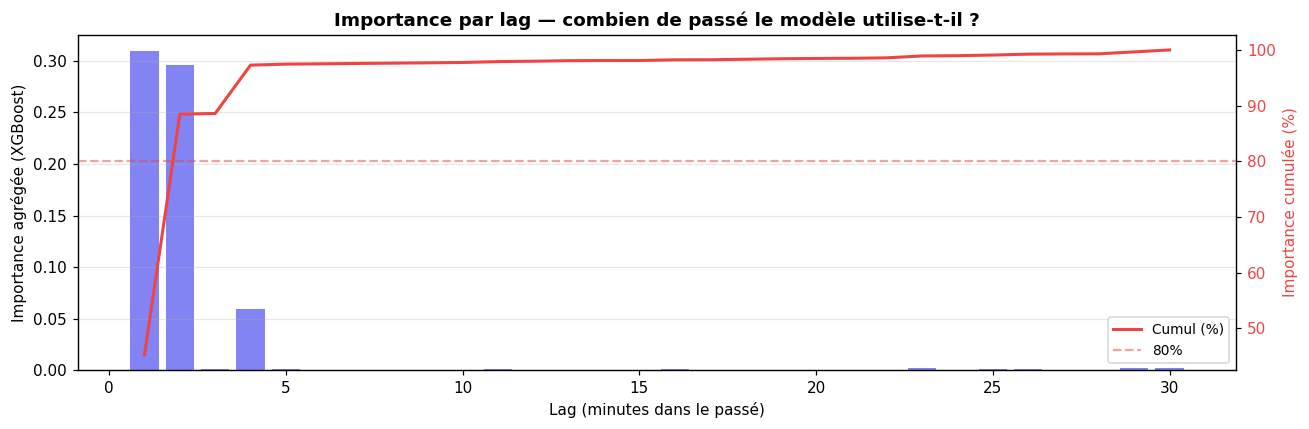

80% de l'importance est capturée avec les 2 premiers lags
→ On pourrait réduire N_LAGS à 2 sans grande perte de performance


In [23]:
# Extraire les importances par numéro de lag
lag_imp = {}
for feat, imp in imp_xgb.items():
    if '_lag' in feat:
        lag_num = int(feat.split('_lag')[-1])
        lag_imp[lag_num] = lag_imp.get(lag_num, 0) + imp

lag_imp_series = pd.Series(lag_imp).sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lag_imp_series.index, lag_imp_series.values, color='#6366F1', alpha=0.8)
ax.set_xlabel('Lag (minutes dans le passé)')
ax.set_ylabel('Importance agrégée (XGBoost)')
ax.set_title('Importance par lag — combien de passé le modèle utilise-t-il ?',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Cumul d'importance
cumsum = lag_imp_series.cumsum() / lag_imp_series.sum() * 100
ax2 = ax.twinx()
ax2.plot(lag_imp_series.index, cumsum, color='#EF4444', linewidth=2,
         label='Cumul (%)')
ax2.set_ylabel('Importance cumulée (%)', color='#EF4444')
ax2.tick_params(axis='y', labelcolor='#EF4444')
ax2.axhline(80, color='#EF4444', linestyle='--', alpha=0.5, label='80%')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Lag à partir duquel on atteint 80% d'importance
lag_80 = int(cumsum[cumsum >= 80].index[0]) if (cumsum >= 80).any() else None
if lag_80:
    print(f"80% de l'importance est capturée avec les {lag_80} premiers lags")
    print(f"→ On pourrait réduire N_LAGS à {lag_80} sans grande perte de performance")

## 8. Conclusions pour le rapport

Résumé des insights de l'analyse d'importance à inclure dans le rapport.

In [24]:
print("=" * 60)
print(" CONCLUSIONS — ANALYSE D'IMPORTANCE")
print("=" * 60)

print("\n📌 Top 10 features les plus importantes (XGBoost) :")
for i, (feat, val) in enumerate(imp_xgb.nlargest(10).items(), 1):
    feat_type = "lag" if '_lag' in feat else "courant"
    print(f"  {i:>2}. {feat:<40} {val:.4f}  [{feat_type}]")

print("\n📌 Top 10 features les plus importantes (Random Forest) :")
for i, (feat, val) in enumerate(imp_rf.nlargest(10).items(), 1):
    feat_type = "lag" if '_lag' in feat else "courant"
    print(f"  {i:>2}. {feat:<40} {val:.4f}  [{feat_type}]")

# Features communes au top 10 des deux modèles
top10_rf  = set(imp_rf.nlargest(10).index)
top10_xgb = set(imp_xgb.nlargest(10).index)
commun    = top10_rf & top10_xgb

print(f"\n📌 Features dans le top 10 des DEUX modèles ({len(commun)}) :")
for f in sorted(commun):
    print(f"  - {f}")

print(f"\n📌 Corrélation Spearman RF vs XGBoost : {corr_spearman:.3f}")

if lag_80:
    print(f"\n📌 Horizon mémoire utile : {lag_80} lags (80% de l'importance)")

print("\n→ Prochaine étape : rapport final")

 CONCLUSIONS — ANALYSE D'IMPORTANCE

📌 Top 10 features les plus importantes (XGBoost) :
   1. 1_LT_001_PV_lag1                         0.3086  [lag]
   2. 1_LT_001_PV                              0.2996  [courant]
   3. 1_LT_001_PV_lag2                         0.2948  [lag]
   4. 1_LT_001_PV_lag4                         0.0592  [lag]
   5. 2_FIC_201_PV                             0.0099  [courant]
   6. 2_FIT_002_PV_lag29                       0.0022  [lag]
   7. 2_FIT_002_PV_lag30                       0.0011  [lag]
   8. 2_FIT_001_PV_lag23                       0.0011  [lag]
   9. 1_FIT_001_PV_lag23                       0.0011  [lag]
  10. 1_FIT_001_PV_lag11                       0.0010  [lag]

📌 Top 10 features les plus importantes (Random Forest) :
   1. 1_LT_001_PV                              0.4759  [courant]
   2. 1_LT_001_PV_lag1                         0.2382  [lag]
   3. 1_LT_001_PV_lag2                         0.1420  [lag]
   4. 1_LT_001_PV_lag3                         0.